<a href="https://colab.research.google.com/github/PolyakovMA/chocolate-review/blob/main/Chocolate_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/PolyakovMA/chocolate-review/main/data/chocolate_train.csv"
train_df = pd.read_csv(url)

train_df.head()

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1255 non-null   object 
 1   Specific Bean Origin  1255 non-null   object 
 2   REF                   1255 non-null   int64  
 3   Review                1255 non-null   int64  
 4   Cocoa Percent         1255 non-null   object 
 5   Company Location      1255 non-null   object 
 6   Rating                1255 non-null   float64
 7   Bean Type             1254 non-null   object 
 8   Broad Bean Origin     1254 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 88.4+ KB


In [4]:
train_df.describe(include='all')

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
count,1255,1255,1255.000000,1255.000000,1255,1255,1255.000000,1254,1254
unique,376,762,NaN,NaN,40,58,NaN,38,84
top,Soma,Madagascar,NaN,NaN,70%,U.S.A.,NaN,,Venezuela
freq,35,39,NaN,NaN,461,521,NaN,628,144
mean,NaN,NaN,1045.152191,2012.382470,NaN,NaN,3.176494,NaN,NaN
std,NaN,NaN,551.284249,2.922499,NaN,NaN,0.478948,NaN,NaN
min,NaN,NaN,5.000000,2006.000000,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,593.000000,2010.000000,NaN,NaN,2.750000,NaN,NaN
50%,NaN,NaN,1077.000000,2013.000000,NaN,NaN,3.250000,NaN,NaN
75%,NaN,NaN,1514.000000,2015.000000,NaN,NaN,3.500000,NaN,NaN


In [12]:
train_df.isna().sum()

,0
Company,0
Specific Bean Origin,0
REF,0
Review,0
Cocoa Percent,0
Company Location,0
Rating,0
Bean Type,1
Broad Bean Origin,1


In [5]:
train_df.loc[   (train_df['Bean Type'].isna())   |
                (train_df['Broad Bean Origin'].isna())
                ]

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
697,Mast Brothers,Madagascar,999,2012,72%,U.S.A.,2.5,Trinitario,NaN
1058,Soma,"Three Amigos(Chuao, Wild Bolivia, D.R.)",676,2011,70%,Canada,4.0,NaN,"Ven, Bolivia, D.R."


In [6]:
train_df.shape

(1255, 9)

In [5]:
train_df = train_df.dropna()
train_df.shape

(1253, 9)

In [6]:
X = train_df.drop('Rating', axis=1)
y = train_df['Rating']

In [7]:
df_numerical = X.select_dtypes(include=['int64', 'float64'])
df_numerical.head()

,REF,Review
0,457,2009
1,508,2010
2,1554,2015
3,1125,2013
4,32,2006


In [8]:
df_categorical = X.select_dtypes(include=['object'])
df_categorical.head()

,Company,Specific Bean Origin,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,72%,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",72%,Switzerland,,Venezuela
2,Dark Forest,Tanzania,70%,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,72%,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",75%,France,Criollo,Indonesia


In [9]:
df_categorical["Cocoa Percent"].unique()

array(['72%', '70%', '75%', '80%', '77%', '68%', '72.5%', '74%', '58%',
       '65%', '82%', '60%', '66%', '64%', '88%', '76%', '81%', '61%',
       '73%', '91%', '67%', '78%', '100%', '85%', '69%', '83%', '62%',
       '71%', '53%', '55%', '90%', '63%', '46%', '86%', '73.5%', '99%',
       '84%', '56%', '50%', '87%'], dtype=object)

In [10]:
df_numerical["Cocoa Percent"] = df_categorical["Cocoa Percent"].str.rstrip('%').astype(float)

df_numerical.head()

,REF,Review,Cocoa Percent
0,457,2009,72.0
1,508,2010,72.0
2,1554,2015,70.0
3,1125,2013,72.0
4,32,2006,75.0


In [11]:
df_categorical = df_categorical.drop(columns=["Cocoa Percent"])
df_categorical.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,,Venezuela
2,Dark Forest,Tanzania,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia


In [12]:
numerical = pd.concat([df_numerical, y], axis=1)
numerical.head()

,REF,Review,Cocoa Percent,Rating
0,457,2009,72.0,3.25
1,508,2010,72.0,3.50
2,1554,2015,70.0,3.00
3,1125,2013,72.0,3.00
4,32,2006,75.0,3.50


<Axes: >

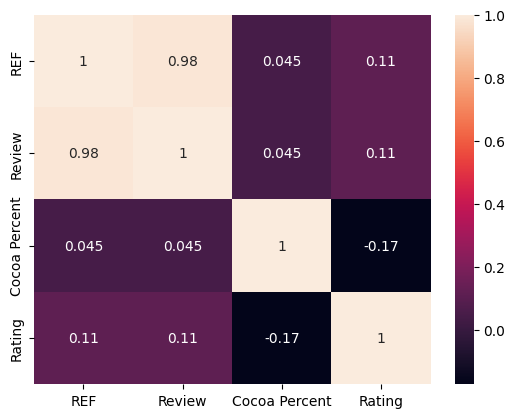

In [13]:
sns.heatmap(numerical.corr(), annot=True)

Text(0, 0.5, 'Rating')

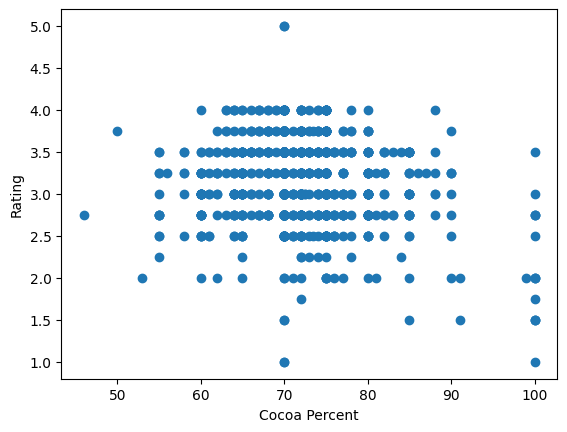

In [14]:
plt.scatter(numerical['Cocoa Percent'], numerical['Rating'])
plt.xlabel('Cocoa Percent')
plt.ylabel('Rating')

Text(0, 0.5, 'Rating')

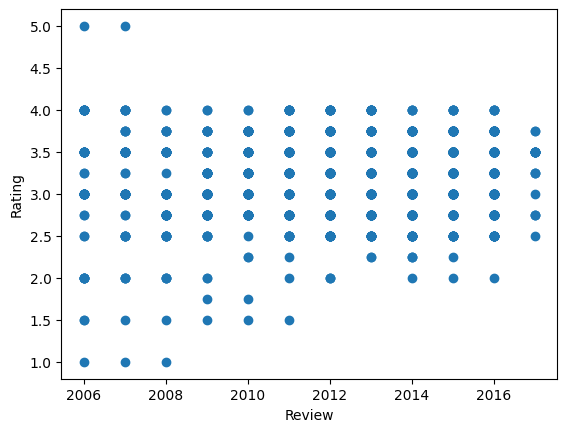

In [17]:
plt.scatter(numerical['Review'], numerical['Rating'])
plt.xlabel('Review')
plt.ylabel('Rating')

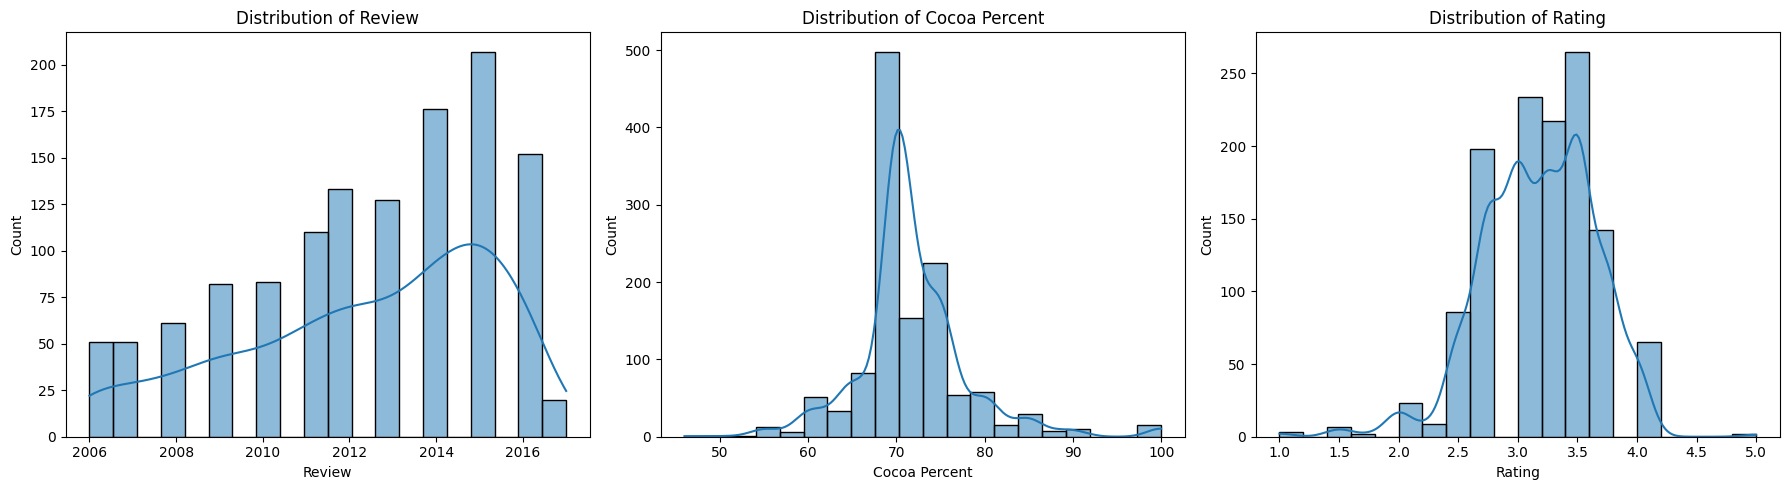

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Review', 'Cocoa Percent', 'Rating']

for i, f in enumerate(features):
    sns.histplot(numerical[f], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribution of {f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
!pip install dython

In [15]:
from dython.nominal import associations

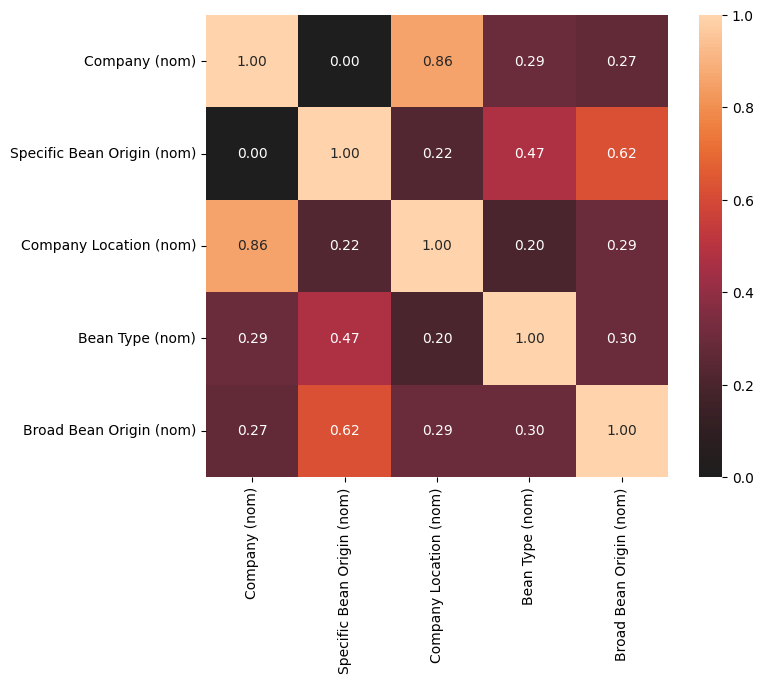

In [18]:
# на тепловой карте отражена V мера крамера (зависимость между категориальными переменными)
assoc = associations(
    df_categorical,
    nominal_columns='all',
    compute_only=False, # чтобы построить тепловую карту
    figsize=(8, 6),
    mark_columns=True
)

In [19]:
for i in df_categorical.columns:
    print(f"{i}: {df_categorical[i].nunique()}")

Company: 376
Specific Bean Origin: 761
Company Location: 58
Bean Type: 38
Broad Bean Origin: 83


In [20]:
for i in df_categorical.columns:
    display(df_categorical[i].value_counts())

,count
Company,
Soma,34
Bonnat,20
A. Morin,19
Fresco,17
Valrhona,16
...,...
Dalloway,1
Amazona,1
Love Bar,1


,count
Specific Bean Origin,
Madagascar,38
Peru,34
Ecuador,31
Dominican Republic,29
Chuao,14
...,...
Phantom,1
"Lachua w/ maple sugar, batch 5",1
"Chulucanas, Batch 1",1


,count
Company Location,
U.S.A.,520
France,116
Canada,88
U.K.,74
Ecuador,42
Italy,41
Australia,32
Switzerland,25
Belgium,25


,count
Bean Type,
,628
Trinitario,284
Criollo,104
Forastero,53
Forastero (Nacional),34
"Criollo, Trinitario",32
Forastero (Arriba),32
Blend,28
Criollo (Porcelana),9


,count
Broad Bean Origin,
Venezuela,144
Ecuador,142
Peru,122
Dominican Republic,104
Madagascar,103
...,...
"Dominican Rep., Bali",1
"Peru, Madagascar",1
"Venezuela, Dom. Rep.",1
